# SQL Join Queries

create database Hosp_mgt

use Hosp_mgt

SELECT COLUMN_NAME
FROM INFORMATION_SCHEMA.COLUMNS
WHERE TABLE_NAME IN ('treatments', 'billing');

SELECT 
    t1.*,       
    t2.bill_id,
    t2.patient_id,
    t2.bill_date,
    t2.amount,
    t2.payment_method,
    t2.payment_status
INTO treatBill
FROM treatments t1
LEFT JOIN billing t2
    ON t1.treatment_id = t2.treatment_id;

select * from treatBill

SELECT 
    t1.*,       
    t2.doctor_id,
    t2.appointment_date,
    t2.appointment_time,
    t2.reason_for_visit,
    t2.status
INTO treatBillApp
FROM treatBill t1
LEFT JOIN appointments t2
    ON t1.appointment_id = t2.appointment_id;

select * from treatBillApp

SELECT 
    t1.*,       
    t2.first_name,
    t2.specialization,
    t2.years_experience,
    t2.hospital_branch
INTO treatBillAppDoc
FROM treatBillApp t1
LEFT JOIN doctors t2
    ON t1.doctor_id = t2.doctor_id;

select * from treatBillAppDoc

SELECT 
    t1.*,       
    t2.gender,
    t2.date_of_birth,
    t2.insurance_provider,
    t2.registration_date
INTO HospRec
FROM treatBillAppDoc t1
LEFT JOIN patients t2
    ON t1.patient_id = t2.patient_id;

select * from HospRec

# Create SQL connection

In [2]:
##Checking system architecture
import platform
print(platform.architecture())

('64bit', 'WindowsPE')


In [3]:
##Listing available ODBC drivers
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [4]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Hosp_mgt;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

In [5]:
##Creating a cursor object
cursor = conn.cursor()

#   Import Libraries & Load Data

In [6]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistics
import scipy.stats as stats
from scipy.stats import pearsonr

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Time Series
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Utilities
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [7]:
df = pd.read_sql("SELECT * FROM HospRec", conn)
df.head()


,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,bill_id,patient_id,bill_date,amount,...,reason_for_visit,status,first_name,specialization,years_experience,hospital_branch,gender,date_of_birth,insurance_provider,registration_date
0,T001,A001,Chemotherapy,Basic screening,3941.969971,2023-08-09,B001,34.0,2023-08-09,3941.969971,...,Therapy,Scheduled,Sarah,Pediatrics,26,Central Hospital,F,1950-01-26,WellnessCorp,2023-06-18
1,T002,A002,MRI,Advanced protocol,4158.439941,2023-06-09,B002,32.0,2023-06-09,4158.439941,...,Therapy,No-show,David,Pediatrics,28,Central Hospital,M,1981-01-08,MedCare Plus,2021-10-02
2,T003,A003,MRI,Standard procedure,3731.550049,2023-06-28,B003,48.0,2023-06-28,3731.550049,...,Consultation,Cancelled,David,Pediatrics,28,Central Hospital,M,1983-03-24,PulseSecure,2023-06-19
3,T004,A004,MRI,Basic screening,4799.859863,2023-09-01,B004,25.0,2023-09-01,4799.859863,...,Consultation,Cancelled,Alex,Pediatrics,23,Central Hospital,M,1966-08-14,HealthIndia,2021-09-09
4,T005,A005,ECG,Standard procedure,582.049988,2023-07-06,B005,40.0,2023-07-06,582.049988,...,Emergency,No-show,Jane,Pediatrics,19,Eastside Clinic,M,1972-05-30,PulseSecure,2021-10-16


# Data Wrangling

Make patient_id column the first column for identification

In [8]:
df= df.set_index("patient_id").sort_index()
df = df.reset_index()
df.head()

,patient_id,treatment_id,appointment_id,treatment_type,description,cost,treatment_date,bill_id,bill_date,amount,...,reason_for_visit,status,first_name,specialization,years_experience,hospital_branch,gender,date_of_birth,insurance_provider,registration_date
0,1.0,T007,A007,Chemotherapy,Advanced protocol,534.030029,2023-04-09,B007,2023-04-09,534.030029,...,Consultation,Scheduled,Robert,Oncology,26,Westside Clinic,F,1955-06-04,WellnessCorp,2022-06-23
1,1.0,T048,A048,Chemotherapy,Advanced protocol,3249.409912,2023-01-16,B048,2023-01-16,3249.409912,...,Emergency,Cancelled,Sarah,Pediatrics,26,Central Hospital,F,1955-06-04,WellnessCorp,2022-06-23
2,1.0,T071,A071,ECG,Advanced protocol,2960.139893,2023-01-26,B071,2023-01-26,2960.139893,...,Follow-up,Scheduled,Alex,Pediatrics,23,Central Hospital,F,1955-06-04,WellnessCorp,2022-06-23
3,1.0,T197,A197,Physiotherapy,Standard procedure,975.489990,2023-04-01,B197,2023-04-01,975.489990,...,Emergency,No-show,Sarah,Dermatology,26,Central Hospital,F,1955-06-04,WellnessCorp,2022-06-23
4,2.0,T082,A082,X-Ray,Basic screening,3615.959961,2023-01-20,B082,2023-01-20,3615.959961,...,Follow-up,Scheduled,Linda,Dermatology,5,Westside Clinic,F,1984-10-12,PulseSecure,2022-01-15


Rename first_name to "doctor"

In [9]:
df = df.rename(columns={"first_name": "doctor"})
df.columns

Index(['patient_id', 'treatment_id', 'appointment_id', 'treatment_type',
       'description', 'cost', 'treatment_date', 'bill_id', 'bill_date',
       'amount', 'payment_method', 'payment_status', 'doctor_id',
       'appointment_date', 'appointment_time', 'reason_for_visit', 'status',
       'doctor', 'specialization', 'years_experience', 'hospital_branch',
       'gender', 'date_of_birth', 'insurance_provider', 'registration_date'],
      dtype='str')

Check for null values

In [10]:
df.isnull().sum()

patient_id            0
treatment_id          0
appointment_id        0
treatment_type        0
description           0
cost                  0
treatment_date        0
bill_id               0
bill_date             0
amount                0
payment_method        0
payment_status        0
doctor_id             0
appointment_date      0
appointment_time      0
reason_for_visit      0
status                0
doctor                0
specialization        0
years_experience      0
hospital_branch       0
gender                0
date_of_birth         0
insurance_provider    0
registration_date     0
dtype: int64

Check data info

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          200 non-null    float64
 1   treatment_id        200 non-null    str    
 2   appointment_id      200 non-null    str    
 3   treatment_type      200 non-null    str    
 4   description         200 non-null    str    
 5   cost                200 non-null    float64
 6   treatment_date      200 non-null    object 
 7   bill_id             200 non-null    str    
 8   bill_date           200 non-null    object 
 9   amount              200 non-null    float64
 10  payment_method      200 non-null    str    
 11  payment_status      200 non-null    str    
 12  doctor_id           200 non-null    float64
 13  appointment_date    200 non-null    object 
 14  appointment_time    200 non-null    object 
 15  reason_for_visit    200 non-null    str    
 16  status             

Convert the different dates column to datetime

In [12]:
df["treatment_date"] = pd.to_datetime(df["treatment_date"])
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"])
df["bill_date"] = pd.to_datetime(df["bill_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

Extract patients age as at 2023

In [13]:
df["year_of_birth"] = df["date_of_birth"].dt.year
df["px_age"] = 2023 - df["year_of_birth"]

Convert appointment time to datetime dtype and extract the hour

In [14]:
df["appointment_time"] = pd.to_datetime(df["appointment_time"], format="%H:%M:%S")
df["hour"] = df["appointment_time"].dt.hour

# Exploratory Data Analysis

## 1. Patient demographics

### a. Gender distribution

In [15]:
gender_dist = df['gender'].value_counts()
gender_dist

gender
M    130
F     70
Name: count, dtype: int64

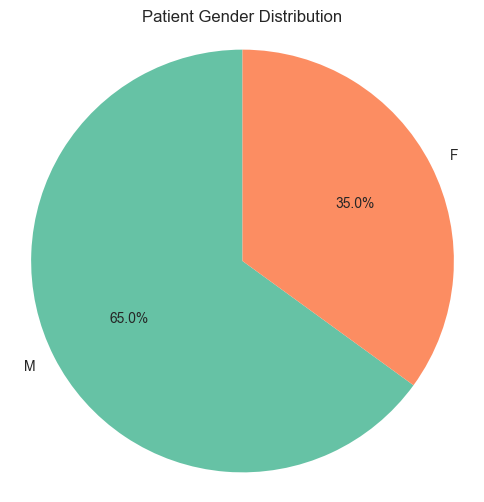

In [16]:
plt.figure(figsize=(6,6))
plt.pie(gender_dist, labels=gender_dist.index, autopct='%1.1f%%', startangle=90)
plt.title("Patient Gender Distribution")
plt.axis('equal')
plt.show()

### b. Age distribution

In [17]:
median_age = df['px_age'].median()
min_age = df['px_age'].min()
max_age = df['px_age'].max()
mode_age = df['px_age'].mode()

print(f"The Median age of patients: {median_age}\n")
print(f"The Oldest patient is: {max_age} years\n")
print(f"The youngest patient is: {min_age} years\n")
print(f"The most frequent patient age is {mode_age}")

The Median age of patients: 36.0

The Oldest patient is: 73 years

The youngest patient is: 18 years

The most frequent patient age is 0    32
Name: px_age, dtype: int32


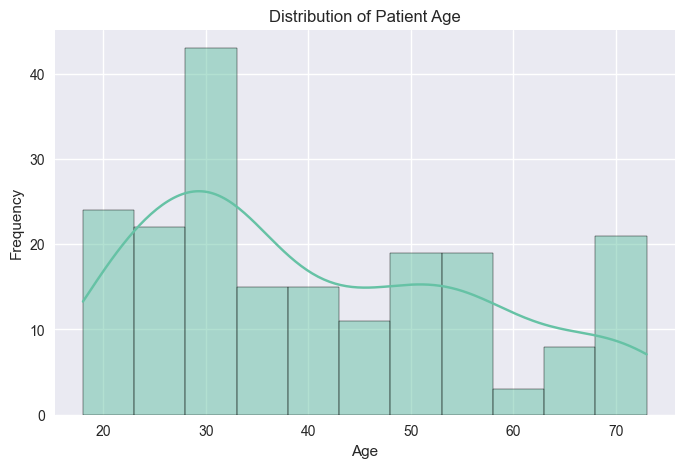

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["px_age"], kde=True, binwidth=5)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

### c. Doctors workload

In [19]:
doctor_patients = (
    df.groupby("doctor")["doctor"]
    .count()
    .reset_index(name="No. of Patients")
    .sort_values(by="No. of Patients", ascending=False)
)

doctor_patients

,doctor,No. of Patients
5,Sarah,46
2,Jane,43
1,David,39
3,Linda,35
0,Alex,24
4,Robert,13


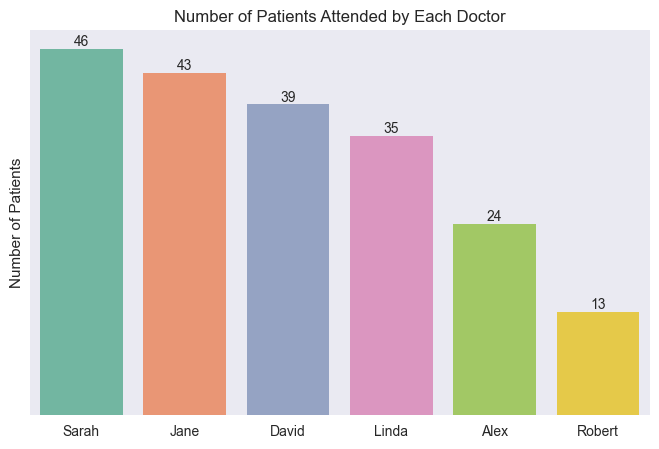

In [20]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=doctor_patients,
    x="doctor",
    y="No. of Patients",
    hue="doctor",
    legend=False
)

plt.title("Number of Patients Attended by Each Doctor")
plt.xlabel("")                    
plt.yticks([])
plt.ylabel("Number of Patients")    

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### d. Experience of doctors

In [21]:
doctor_experience = (
    df.groupby("doctor")["years_experience"]
    .mean().round()
    .reset_index(name="Experience(years)")       
    .sort_values(by="Experience(years)", ascending=False)  
)

doctor_experience

,doctor,Experience(years)
4,Robert,26.0
5,Sarah,26.0
0,Alex,23.0
1,David,21.0
2,Jane,21.0
3,Linda,14.0


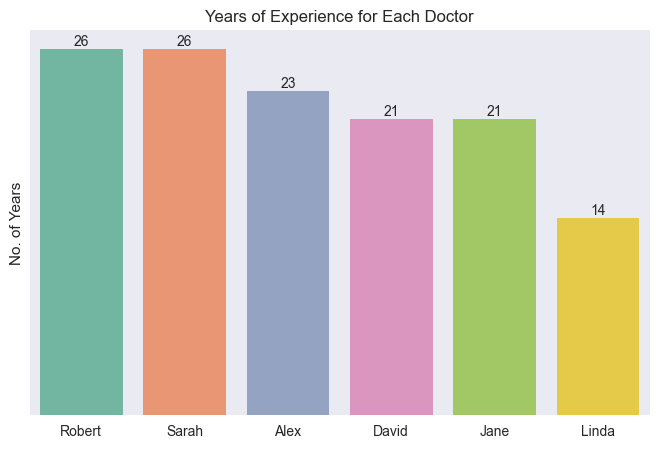

In [22]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=doctor_experience,
    x="doctor",
    y="Experience(years)",
    hue="doctor",
    legend=False
)

plt.title("Years of Experience for Each Doctor")
plt.xlabel("")    
plt.yticks([])                  
plt.ylabel("No. of Years")   

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### e. Distribution of patients across departments

In [23]:
px_dist = (
    df['specialization']
    .value_counts()
    .reset_index(name="Patients")       
    .sort_values(by="Patients", ascending=False)  
)

px_dist

,specialization,Patients
0,Pediatrics,98
1,Dermatology,70
2,Oncology,32


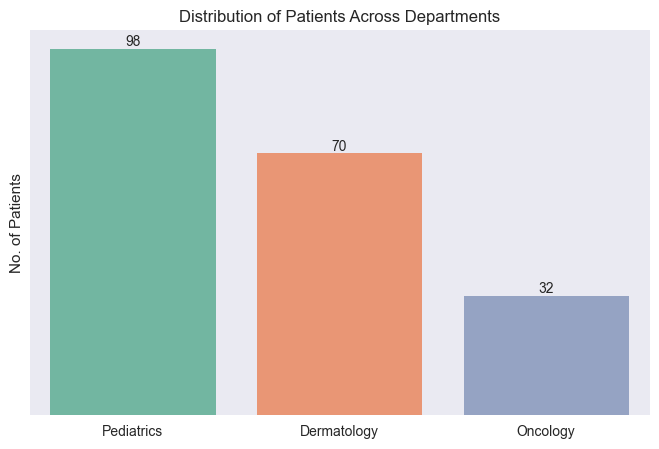

In [24]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=px_dist,
    x="specialization",
    y="Patients",
    hue="specialization",
    legend=False
)

plt.title("Distribution of Patients Across Departments")
plt.xlabel("") 
plt.yticks([])                     
plt.ylabel("No. of Patients")    

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### f. Distribution of patients across branches

In [25]:
branch_dist = (
    df['hospital_branch']
    .value_counts()
    .reset_index(name="Patients")       
    .sort_values(by="Patients", ascending=False)  
)

branch_dist

,hospital_branch,Patients
0,Central Hospital,84
1,Eastside Clinic,62
2,Westside Clinic,54


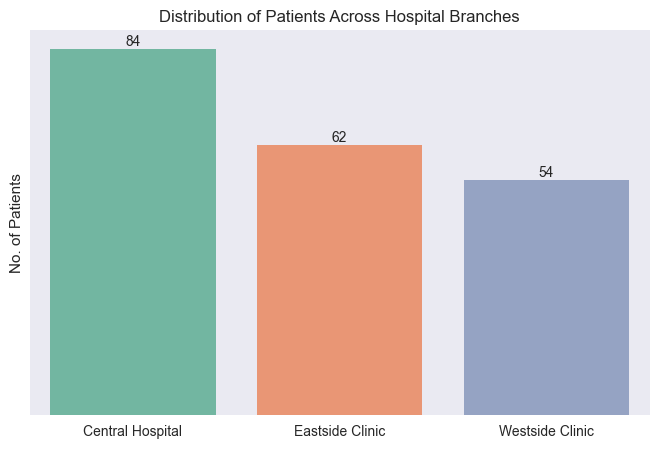

In [26]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=branch_dist,
    x="hospital_branch",
    y="Patients",
    hue="hospital_branch",
    legend=False
)

plt.title("Distribution of Patients Across Hospital Branches")
plt.xlabel("")  
plt.yticks([])                   
plt.ylabel("No. of Patients")  

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

## 2. Financial KPIs

### a. Total Revenue

In [27]:
total_rev = pd.DataFrame({
    "Total Rev($)": [df["amount"].sum().round(2)]
})

total_rev

,Total Rev($)
0,551249.85


### b. Revenue per branch

In [28]:
branch_rev = (
    df.groupby('hospital_branch')['amount']
    .sum()
    .reset_index(name="Revenue($)")       
    .sort_values(by="Revenue($)", ascending=False)
    .round(2)  
)

branch_rev

,hospital_branch,Revenue($)
0,Central Hospital,229039.44
1,Eastside Clinic,162031.10
2,Westside Clinic,160179.31


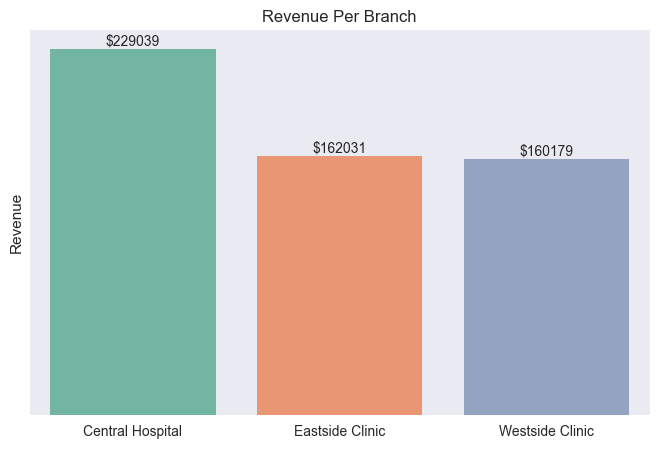

In [29]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=branch_rev,
    x="hospital_branch",
    y="Revenue($)",
    hue="hospital_branch",
    legend=False
)

plt.title("Revenue Per Branch")
plt.xlabel("")  
plt.yticks([])                   
plt.ylabel("Revenue")  

# Add values on top of each bar
for p in ax.patches:
    ax.annotate(
        f'${int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

### c. Failed payment rate

In [30]:
df['payment_status'].unique()

<StringArray>
['Failed', 'Paid', 'Pending']
Length: 3, dtype: str

In [31]:
payment_rate = (
    df['payment_status']
    .value_counts()
    .reset_index(name="Count")
)

# Add percentage column
payment_rate["Rate (%)"] = (
    payment_rate["Count"] / payment_rate["Count"].sum() * 100
).round(2)

payment_rate = payment_rate.sort_values(by="Count", ascending=False)

payment_rate

,payment_status,Count,Rate (%)
0,Pending,69,34.5
1,Failed,67,33.5
2,Paid,64,32.0


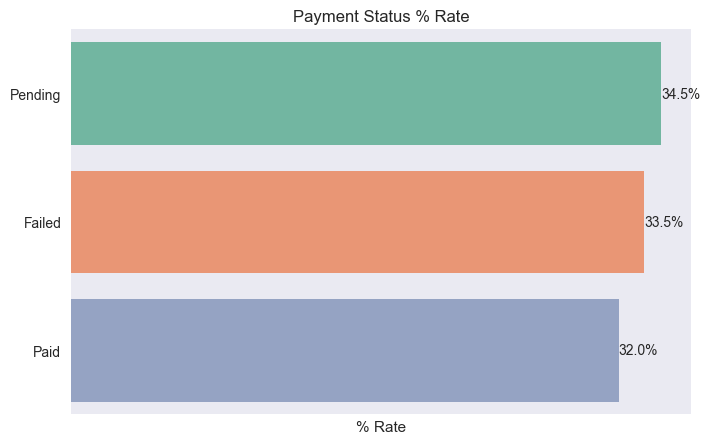

In [32]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=payment_rate,
    x="Rate (%)",
    y="payment_status",
    hue="payment_status",
    legend=False
)

plt.title("Payment Status % Rate")
plt.ylabel("")
plt.xticks([])
plt.xlabel("% Rate")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

### d. Payment method success rate

In [33]:
pay_status = pd.pivot_table(
    df,
    index="payment_method",
    columns="payment_status",
    values="amount",
    aggfunc="sum"
)

# Convert to percentages
pay_status_pct = (pay_status.div(pay_status.sum(axis=1), axis=0) * 100).round()

pay_status_pct

payment_status,Failed,Paid,Pending
payment_method,,,
Cash,39.0,31.0,29.0
Credit Card,32.0,30.0,38.0
Insurance,34.0,33.0,33.0


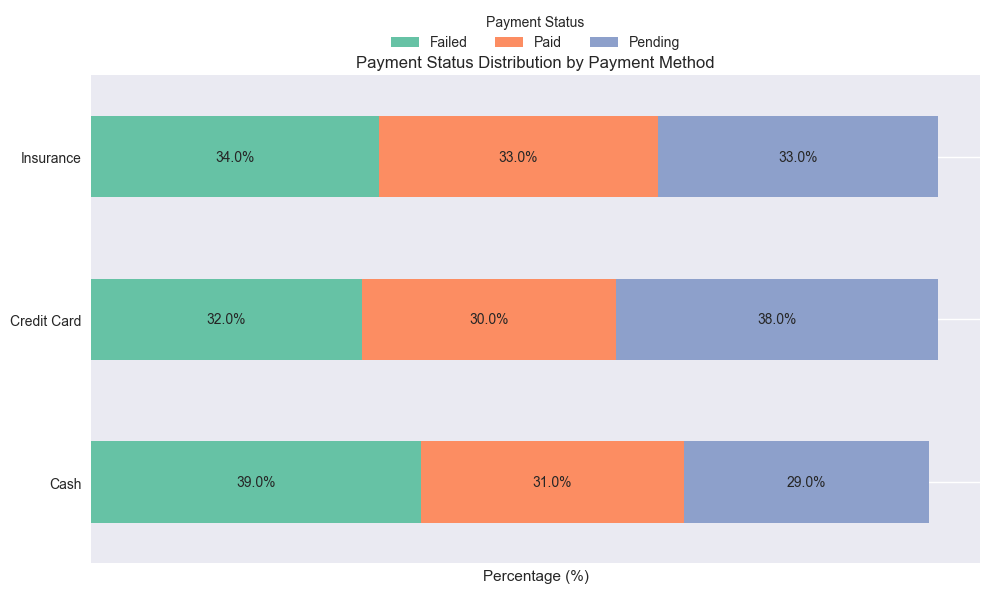

In [34]:
ax = pay_status_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Status Distribution by Payment Method")
plt.ylabel("")       # remove y-axis label
plt.xlabel("Percentage (%)")
plt.xticks([])  # keep x-axis numbers horizontal

# Add data labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

# Horizontal legend at top
plt.legend(
    title="Payment Status",
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
    ncol=len(pay_status_pct.columns)
)

plt.tight_layout()
plt.show()

## 3. Operational KPIs

### a. Appointment volume by hour

In [35]:
rush_hour = (
    df['hour']
    .value_counts()
    .reset_index(name="Count")
    .sort_values("hour")
    .set_index("hour")

)

rush_hour


,Count
hour,
8,21
9,17
10,19
11,18
12,21
13,20
14,20
15,28
16,15


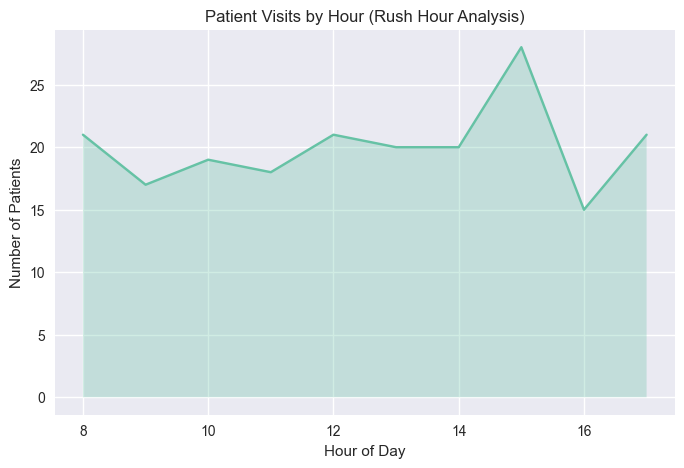

In [36]:
plt.figure(figsize=(8,5))

plt.plot(rush_hour.index, rush_hour["Count"])
plt.fill_between(rush_hour.index, rush_hour["Count"], alpha=0.3)

plt.title("Patient Visits by Hour (Rush Hour Analysis)")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Patients")

plt.show()

### b. Appointment status

In [37]:
status_rate = (
    df['status']
    .value_counts()
    .reset_index(name="Count")
)

# Add percentage column
status_rate["Rate (%)"] = (
    status_rate["Count"] / status_rate["Count"].sum() * 100
).round(2)

status_rate = status_rate.sort_values(by="Count", ascending=False)

status_rate

,status,Count,Rate (%)
0,No-show,52,26.0
1,Scheduled,51,25.5
2,Cancelled,51,25.5
3,Completed,46,23.0


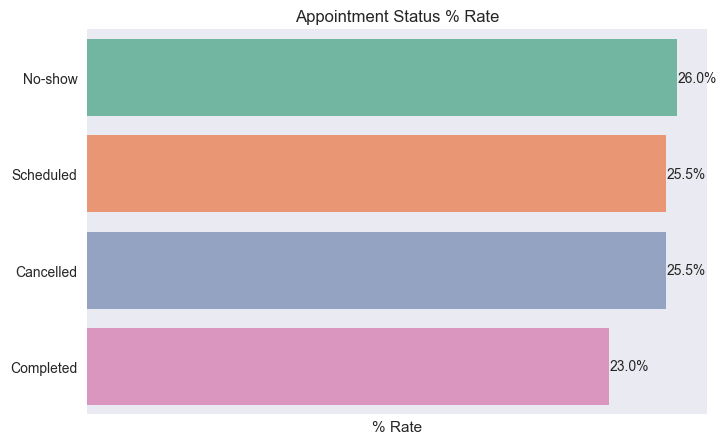

In [38]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=status_rate,
    x="Rate (%)",
    y="status",
    hue="status",
    legend=False
)

plt.title("Appointment Status % Rate")
plt.ylabel("")
plt.xticks([])
plt.xlabel("% Rate")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

## 4. Clinical KPIs

### a. Most common treatments

In [39]:
common_tx = (df['treatment_type']
             .value_counts()
             .reset_index(name="Counts")
             .sort_values(by="Counts", ascending = False))

common_tx["Rate (%)"] = (common_tx['Counts']/common_tx['Counts'].sum())*100
common_tx = common_tx.set_index("treatment_type")
common_tx

,Counts,Rate (%)
treatment_type,,
Chemotherapy,49,24.5
X-Ray,41,20.5
ECG,38,19.0
Physiotherapy,36,18.0
MRI,36,18.0


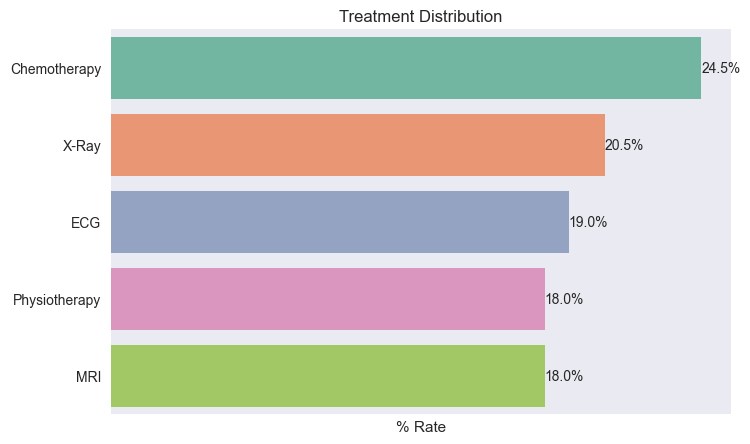

In [40]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=common_tx,
    x="Rate (%)",
    y="treatment_type",
    hue="treatment_type",
    legend=False
)

plt.title("Treatment Distribution")
plt.ylabel("")
plt.xticks([])
plt.xlabel("% Rate")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

### b. Revenue by treatment

In [41]:
treatment_rev = (
    df.pivot_table(
        index="treatment_type",
        values="amount",
        aggfunc=["mean", "sum"]
    )
)

# Rename columns
treatment_rev.columns = ["Average Cost ($)", "Total Revenue ($)"]

# Add percentage contribution column
treatment_rev["Revenue Share (%)"] = (
    treatment_rev["Total Revenue ($)"] /
    treatment_rev["Total Revenue ($)"].sum() * 100
).round(2)

# Round values
treatment_rev = treatment_rev.sort_values(by="Revenue Share (%)", ascending = False).round(2)

treatment_rev

,Average Cost ($),Total Revenue ($),Revenue Share (%)
treatment_type,,,
Chemotherapy,2629.71,128855.68,23.38
MRI,3224.95,116098.16,21.06
X-Ray,2698.87,110653.67,20.07
Physiotherapy,2761.61,99418.10,18.04
ECG,2532.22,96224.24,17.46


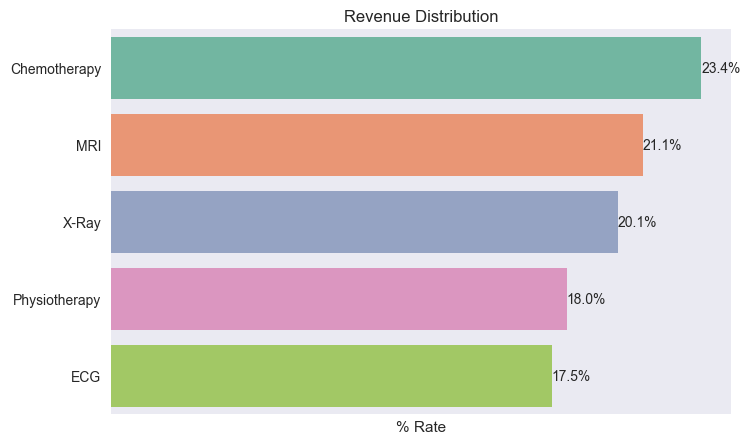

In [42]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=treatment_rev,
    x="Revenue Share (%)",
    y="treatment_type",
    hue="treatment_type",
    legend=False
)

plt.title("Revenue Distribution")
plt.ylabel("")
plt.xticks([])
plt.xlabel("% Rate")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

### c. Average cost per treatment

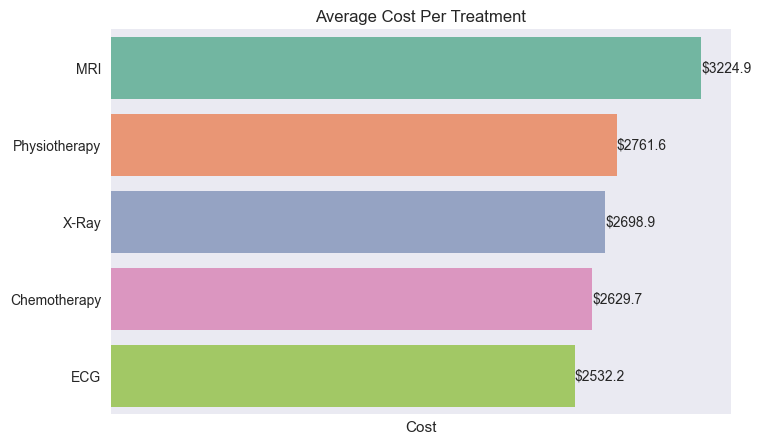

In [43]:
plt.figure(figsize=(8,5))

treatment_rev = treatment_rev.sort_values(by="Average Cost ($)", ascending = False)

ax = sns.barplot(
    data=treatment_rev,
    x="Average Cost ($)",
    y="treatment_type",
    hue="treatment_type",
    legend=False
)

plt.title("Average Cost Per Treatment")
plt.ylabel("")
plt.xticks([])
plt.xlabel("Cost")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'${p.get_width():.1f}',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

### d. Treatment distribution Vs Revenue generation

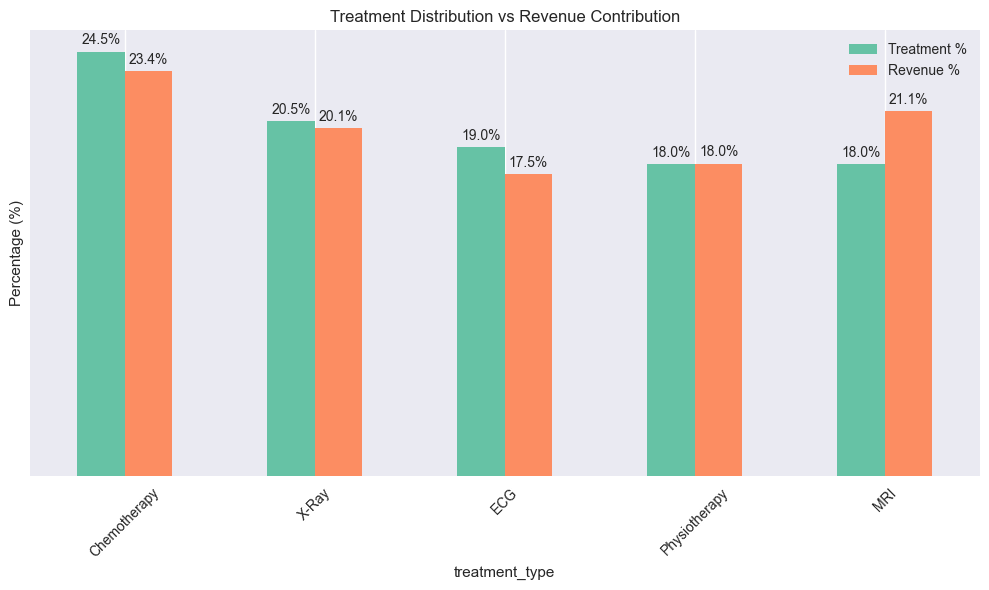

In [44]:
# Treatment frequency %
treatment_pct = (
    df['treatment_type']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Treatment %')
)

# Revenue distribution %
revenue_pct = (
    df.groupby('treatment_type')['amount']
    .sum()
    .pipe(lambda x: x / x.sum() * 100)
    .rename('Revenue %')
)

# Combine
tx_distribution = pd.concat([treatment_pct, revenue_pct], axis=1).reset_index()
tx_distribution.rename(columns={'index':'treatment_type'}, inplace=True)

# Plot
ax = tx_distribution.set_index('treatment_type').plot(kind='bar', figsize=(10,6))

plt.ylabel('Percentage (%)')
plt.yticks([])
plt.title('Treatment Distribution vs Revenue Contribution')
plt.xticks(rotation=45)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

### e. Treatment trend by age

In [45]:
df["age_group"] = pd.cut(
    df["px_age"],
    bins=[0,18,30,45,60,75,100],
    labels=["0-18","19-30","31-45","46-60","61-75","76+"]
)

age_treatment_trend = pd.pivot_table(
    df,
    index="age_group",
    columns="treatment_type",
    values="patient_id",
    aggfunc="count"
)

age_treatment_trend = age_treatment_trend.fillna(0)
age_treatment_trend

treatment_type,Chemotherapy,ECG,MRI,Physiotherapy,X-Ray
age_group,,,,,
0-18,3.0,1.0,0.0,2.0,1.0
19-30,13.0,13.0,15.0,12.0,9.0
31-45,13.0,7.0,10.0,9.0,16.0
46-60,14.0,11.0,8.0,6.0,8.0
61-75,6.0,6.0,3.0,7.0,7.0


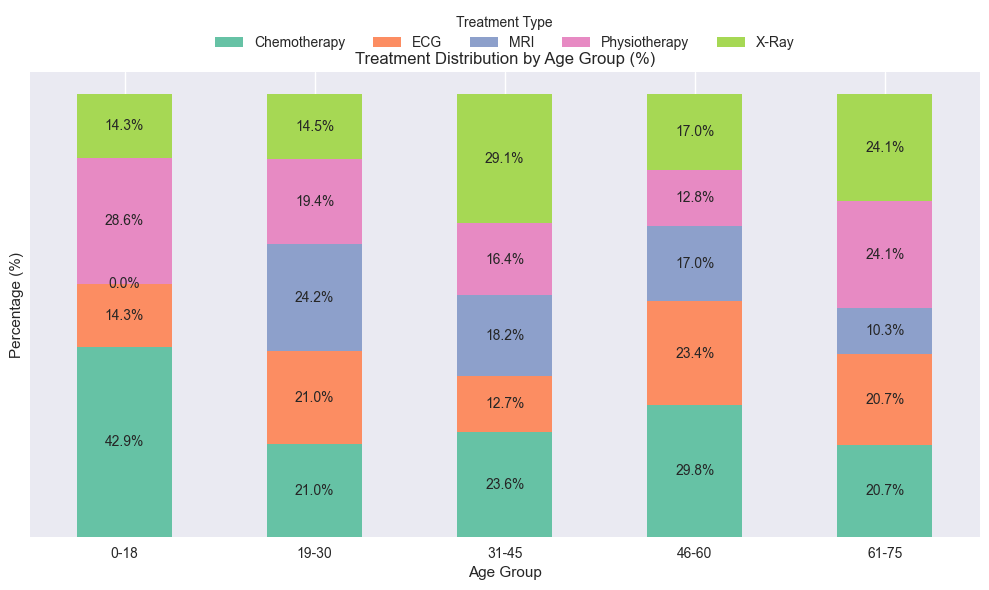

In [46]:
age_treatment_pct = age_treatment_trend.div(
    age_treatment_trend.sum(axis=1), axis=0
) * 100

ax = age_treatment_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Treatment Distribution by Age Group (%)")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.yticks([])
plt.xticks(rotation=0)

# Add data labels on each segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

# Move legend to top and make horizontal
plt.legend(
    title="Treatment Type",
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
    ncol=len(age_treatment_pct.columns)
)

plt.tight_layout()
plt.show()

## Insurance KPIs

### a. Distribution of insurance providers

In [47]:
df1 = df[df['payment_method']=="Insurance"]

In [48]:
insurance = (df1['insurance_provider']
             .value_counts()
             .reset_index(name="Counts")
             .sort_values(by="Counts", ascending = False))

insurance["Rate (%)"] = ((insurance['Counts']/insurance['Counts'].sum())*100).round()
insurance = insurance.set_index("insurance_provider")
insurance

,Counts,Rate (%)
insurance_provider,,
MedCare Plus,33,52.0
WellnessCorp,14,22.0
PulseSecure,12,19.0
HealthIndia,5,8.0


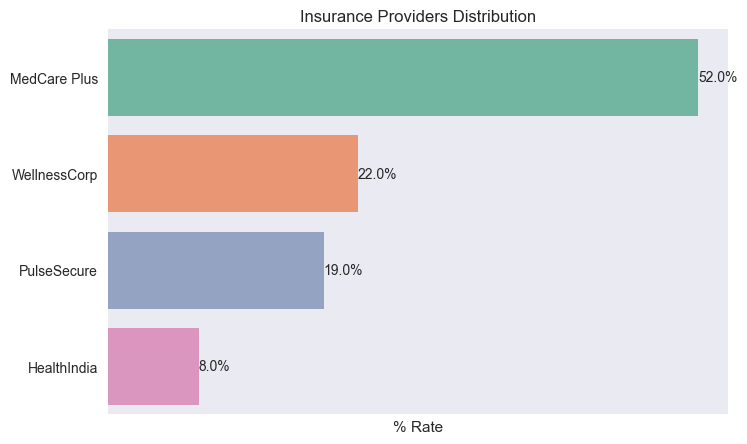

In [49]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=insurance,
    x="Rate (%)",
    y="insurance_provider",
    hue="insurance_provider",
    legend=False
)

plt.title("Insurance Providers Distribution")
plt.ylabel("")
plt.xticks([])
plt.xlabel("% Rate")


# Add percentage labels at the end of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.show()

### b. Payment status rate by insurance provider

In [50]:
insure_pay = pd.pivot_table(
    df1,
    index="insurance_provider",
    columns="payment_status",
    values="patient_id",
    aggfunc="count"
).fillna(0)

# Convert to percentages
insure_pay_pct = (insure_pay.div(insure_pay.sum(axis=1), axis=0) * 100).round()

insure_pay_pct

payment_status,Failed,Paid,Pending
insurance_provider,,,
HealthIndia,60.0,0.0,40.0
MedCare Plus,30.0,33.0,36.0
PulseSecure,17.0,42.0,42.0
WellnessCorp,43.0,29.0,29.0


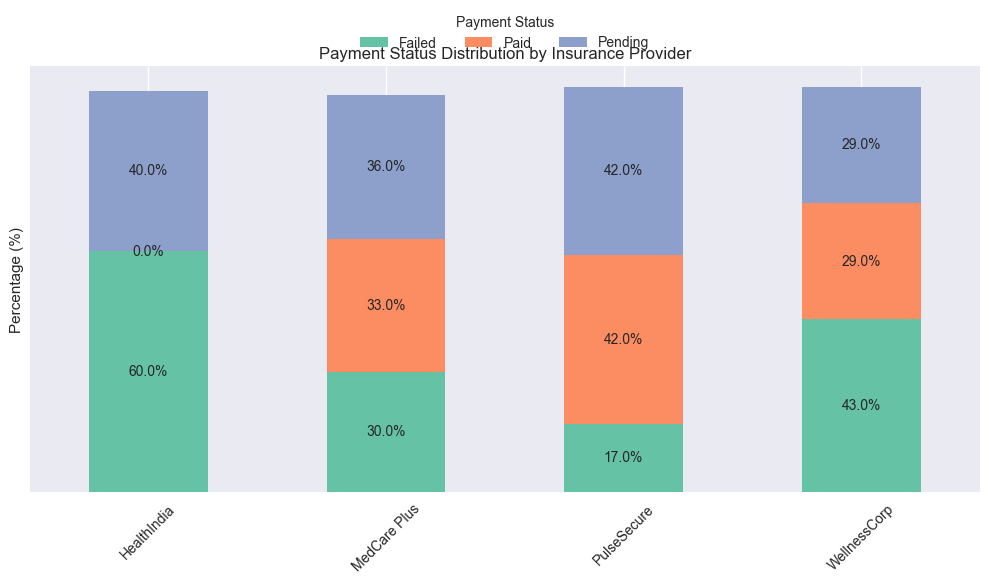

In [51]:
ax = insure_pay_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Status Distribution by Insurance Provider")
plt.xlabel("")
plt.ylabel("Percentage (%)")
plt.yticks([])
plt.xticks(rotation=45)

# Add data labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

# Horizontal legend at top
plt.legend(
    title="Payment Status",
    bbox_to_anchor=(0.5, 1.15),
    loc="upper center",
    ncol=len(insure_pay_pct.columns)
)

plt.tight_layout()
plt.show()

# Advanced Analytics

## 1. Predict treatment cost

a. Select features

In [52]:
df2 = df[[
    "treatment_type",
    "insurance_provider",
    "cost",
    "doctor",
    "hospital_branch",
    "gender",
    "px_age",
    "hour"
]]

b. Standardize numerical variables

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df2.select_dtypes(include="number").columns

df2[num_cols] = scaler.fit_transform(df2[num_cols])

df2[num_cols].describe()

,cost,px_age,hour
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-1.154632e-16,1.354472e-16,6.661338e-17
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.716164e+00,-1.417554e+00,-1.607619e+00
25%,-9.211977e-01,-7.319924e-01,-9.071317e-01
50%,5.553876e-02,-2.957262e-01,1.436000e-01
75%,8.343488e-01,7.637775e-01,8.440878e-01
max,1.712427e+00,2.010253e+00,1.544576e+00


c. Encode categorical variables

In [54]:
# One-hot columns
onehot_cols = ["gender"]

df2 = pd.get_dummies(df2, columns=onehot_cols, drop_first=True)

# Frequency encoding
freq_cols = ["doctor","hospital_branch","treatment_type","insurance_provider"]

for col in freq_cols:
    freq = df2[col].value_counts()
    df2[col] = df2[col].map(freq)

d. Check the correlation with cost

In [55]:
df2.corr(numeric_only=True)['cost'].abs().sort_values(ascending=False)

cost                  1.000000
doctor                0.108616
hour                  0.091143
treatment_type        0.082492
insurance_provider    0.065077
px_age                0.060763
hospital_branch       0.043011
gender_M              0.023376
Name: cost, dtype: float64

e. Assign features

In [56]:
X = df2[['treatment_type', 'insurance_provider', 'doctor',
       'hospital_branch', 'px_age', 'hour', 'gender_M']]

y = df2['cost']

f. Split into test and train

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

g. Check feature importance using RandomforestRegressor

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

import pandas as pd

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

print(feature_importance)

              Feature  Importance
4              px_age    0.290876
5                hour    0.231354
2              doctor    0.130014
0      treatment_type    0.125758
1  insurance_provider    0.109270
3     hospital_branch    0.066215
6            gender_M    0.046512


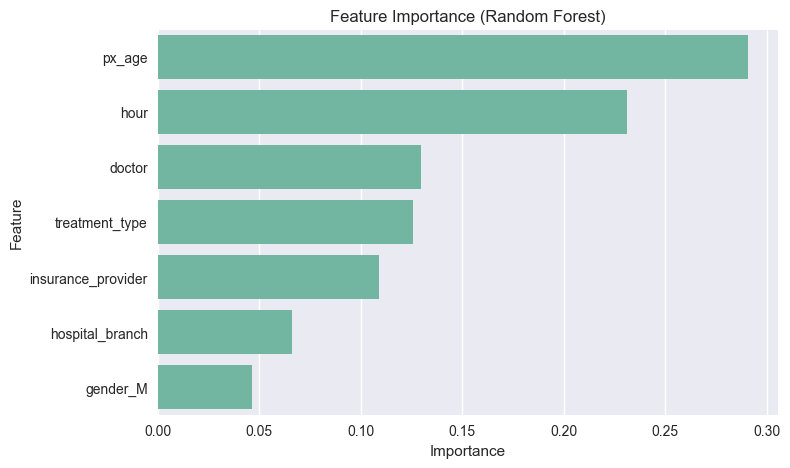

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance (Random Forest)")
plt.show()

h. Multiple Linear Regression Model

In [60]:

from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)


Coefficients:  [-0.01539561  0.00667551 -0.01139207 -0.00195791  0.10012713  0.14030626
  0.25481948]
Intercept:  0.6264867883505589


In [61]:
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 1.20
R-squared: -0.22


i. Multiple Linear Regression using repeated k-fold cross validation

In [62]:
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Define repeated k-fold
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

# Run cross validation
scores = cross_val_score(
    model,
    X,
    y,
    scoring='r2',
    cv=cv,
    n_jobs=-1
)

print("R2 scores:", scores)
print("Mean R2:", scores.mean())
print("Std Dev:", scores.std())

R2 scores: [-0.22152197  0.02505161 -0.14490904  0.02691001 -0.14155425 -0.21742092
 -0.40943526  0.03028262 -0.10133844 -0.01839734 -0.26705034 -0.00714366
 -0.02908091 -0.28825988 -0.13756623 -0.2844219  -0.09999525  0.01135768
 -0.11246681 -0.07578878 -0.13708389  0.03631541 -0.07443409 -0.05912311
  0.01121681  0.04391359 -0.04830104  0.03150374 -0.0471191  -0.17453165
 -0.13806278 -0.00328786 -0.05988749 -0.07536686 -0.01980788 -0.06987338
 -0.38348754 -0.01309502  0.03513331 -0.13055928 -0.08105036  0.02987525
  0.08268804 -0.02829067 -0.09202572 -0.31304213 -0.18793477 -0.03996035
 -0.09456614 -0.11272876]
Mean R2: -0.09151445590018081
Std Dev: 0.11218401487284227


j. Support Vector Regression Model

In [63]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=100, epsilon=0.1)  # create the model


# Train the model
svr.fit(X_train, y_train)

# Predict on test data
y_pred = svr.predict(X_test)  # No scaling applied

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())

Mean Squared Error: 1.3397959325853859
R-squared: -0.3601773554581844
       Actual  Predicted
95   1.479718  -0.871954
15  -0.660580   0.494544
30  -1.591573  -0.168048
158  1.308720  -0.061436
128 -0.989222   0.138993


k. Decision Tree Regression model

In [64]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

dt_reg.fit(X_train, y_train)

# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 1.888
R^2 score : -0.917


l. Multiple Linear Regression using cross validation

In [65]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import linear_model
 
# model
regressor = linear_model.LinearRegression()

# cross validation on training set
cv_scores = cross_val_score(regressor, X_train, y_train, cv=5, scoring='r2')

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

# train final model
regressor.fit(X_train, y_train)


CV R2 scores: [ 0.00084997  0.04276857  0.06540462  0.04661794 -0.30461501]
Mean CV R2: -0.02979478402663498


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


m. Model Evaluation

In [66]:
from sklearn.metrics import mean_squared_error, r2_score

# predictions
y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

# training metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# test metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

print("Training R2:", train_r2)
print("Test R2:", test_r2)

Training MSE: 0.9225421731764711
Test MSE: 1.2032182102231963
Training R2: 0.07899726473778168
Test R2: -0.22152196720168504


| Situation                    | Meaning                |
| ---------------------------- | ---------------------- |
| Train R² ≈ Test R²           | Model generalizes well |
| Train R² >> Test R²          | **Overfitting**        |
| Train R² low and Test R² low | **Underfitting**       |


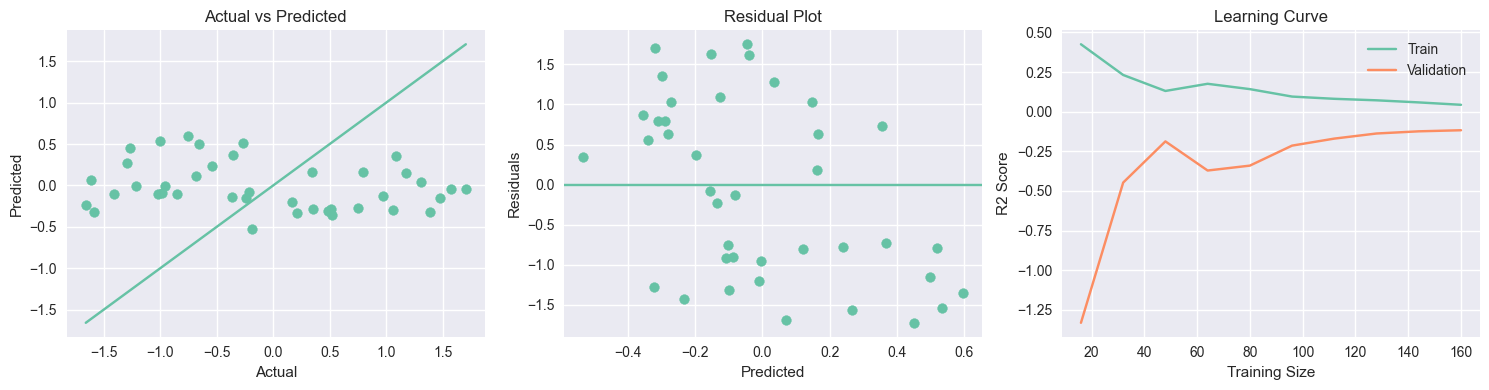

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# predictions
y_pred = regressor.predict(X_test)

# residuals
residuals = y_test - y_pred

plt.figure(figsize=(15,4))

# 1️⃣ Actual vs Predicted
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")


# 2️⃣ Residual Plot
plt.subplot(1,3,2)
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")


# 3️⃣ Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    regressor,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.subplot(1,3,3)
plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

All models gave a negative R-square which indicates that the model is poor. Further evaluation indicates **underfitting** and this can be due to dataset not large enough for training.

## 2. Payment Status Classification

In [68]:
df['specialization'].unique()

<StringArray>
['Oncology', 'Pediatrics', 'Dermatology']
Length: 3, dtype: str

In [69]:
df3 = df[[
    "treatment_type",
    "specialization",
    "cost",
    "doctor",
    "hospital_branch",
    "gender",
    "px_age",
    "hour",
    "payment_status",
    "insurance_provider"
]]

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df3.select_dtypes(include="number").columns

df3[num_cols] = scaler.fit_transform(df3[num_cols])

# One-hot columns
onehot_cols = ["gender"]

df3 = pd.get_dummies(df3, columns=onehot_cols, drop_first=True)

# Frequency encoding
freq_cols = ["doctor","hospital_branch","specialization","insurance_provider"]

for col in freq_cols:
    freq = df3[col].value_counts()
    df3[col] = df3[col].map(freq)

In [71]:
df['treatment_type'].unique()

<StringArray>
['Chemotherapy', 'ECG', 'Physiotherapy', 'X-Ray', 'MRI']
Length: 5, dtype: str

In [72]:
custom_map = {'Chemotherapy':0,'ECG':1,'Physiotherapy':2,'X-Ray':3,'MRI':4}
df3['treatment_type'] = df3['treatment_type'].map(custom_map)
df3

,treatment_type,specialization,cost,doctor,hospital_branch,px_age,hour,payment_status,insurance_provider,gender_M
0,0,32,-1.716164,13,54,1.698634,-0.907132,Failed,58,False
1,0,98,0.380856,46,84,1.698634,0.844088,Failed,58,False
2,1,98,0.157460,24,84,1.698634,1.544576,Paid,58,False
3,2,70,-1.375235,46,84,1.698634,0.143600,Pending,58,False
4,3,70,0.663933,35,54,-0.108755,-0.907132,Pending,36,False
...,...,...,...,...,...,...,...,...,...,...
195,0,70,0.195988,46,84,0.639130,0.493844,Failed,84,True
196,0,70,0.061412,39,54,-0.669669,0.493844,Failed,58,True
197,1,70,1.702403,39,54,-0.669669,-0.206644,Pending,58,True
198,4,98,-1.158558,39,84,-0.669669,-1.257376,Failed,58,True


In [73]:
X = df3[['cost', 'hospital_branch', 'gender_M']]

y = df3['treatment_type']

In [74]:
corr_df3 = df3.corr(numeric_only=True)['treatment_type'].abs().sort_values(ascending = False)
corr_df3

treatment_type        1.000000
cost                  0.139989
gender_M              0.108618
hospital_branch       0.056497
px_age                0.046622
insurance_provider    0.034711
specialization        0.020895
doctor                0.017450
hour                  0.015257
Name: treatment_type, dtype: float64

In [75]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32)

In [76]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

X_trainset, X_testset, y_trainset, y_testset = train_test_split(X, y, test_size=0.3, random_state=32)

drugTree = DecisionTreeClassifier(criterion="entropy", max_depth = 4)

drugTree.fit(X_trainset,y_trainset)

tree_predictions = drugTree.predict(X_testset)

print("Decision Trees's Accuracy: ", metrics.accuracy_score(y_testset, tree_predictions))

Decision Trees's Accuracy:  0.23333333333333334


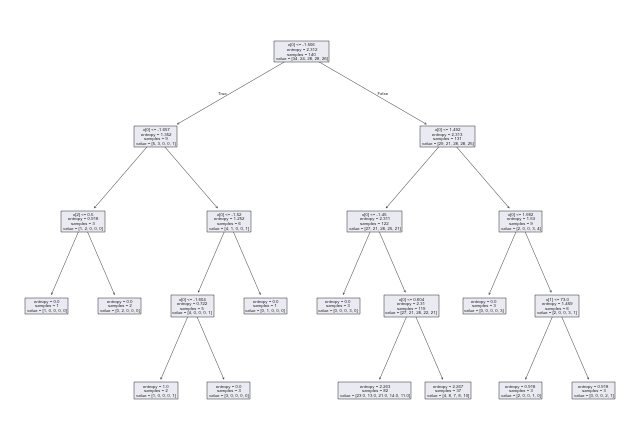

In [77]:
plot_tree(drugTree)
plt.show()

In [78]:
X.columns

Index(['cost', 'hospital_branch', 'gender_M'], dtype='str')

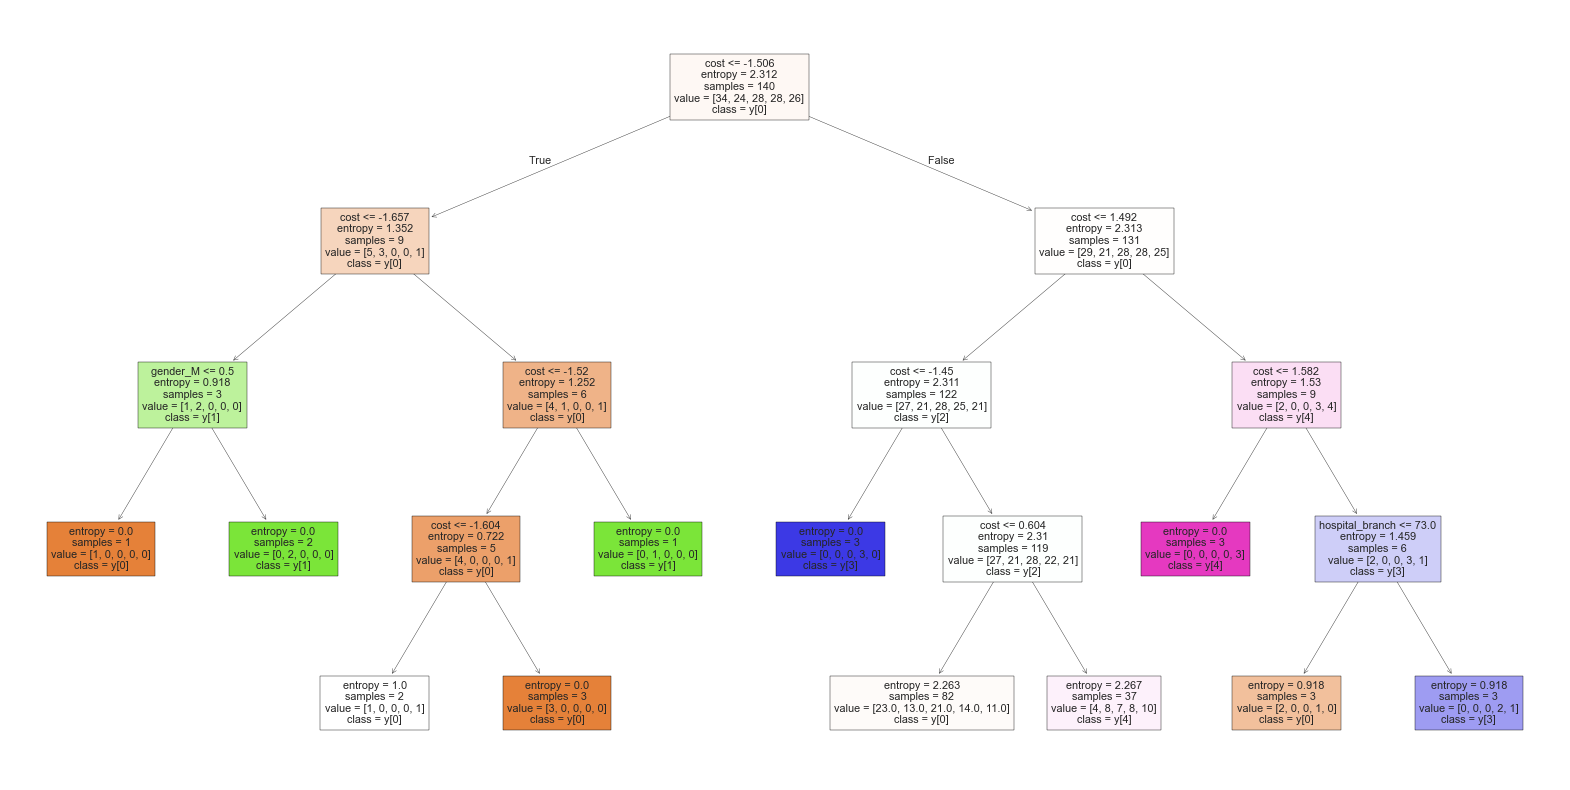

In [79]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(drugTree,
          feature_names=X.columns,
          class_names=True,
          filled=True)

plt.show()

## Conclusion

The Decision Tree model had an accuracy score of 15% which is very poor. This could be attributed to the limited dataset.